# Autoencoder Clustering (Separate Notebook)

This notebook runs the Autoencoder-based clustering pipeline only.
K-means baseline is in `AI/K_mean.ipynb`.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, v_measure_score

TF_AVAILABLE = True
try:
    import tensorflow as tf
    from tensorflow.keras import layers, Model
except Exception as e:
    TF_AVAILABLE = False
    TF_IMPORT_ERROR = str(e)

sns.set_theme(style='whitegrid')
np.random.seed(42)

if not TF_AVAILABLE:
    print('TensorFlow not available. PCA fallback will be used for latent features.')
    print(f'Reason: {TF_IMPORT_ERROR}')

In [2]:
X_scaled = pd.read_csv(os.path.join('data', 'data_preprocessed.csv'))
raw_df = pd.read_csv(os.path.join('data', 'Shopping Mall Customer Segmentation Data .csv'))
reference_labels = raw_df['Gender'].astype(str)

print(f'Scaled feature matrix shape: {X_scaled.shape}')
print(f'Raw data shape: {raw_df.shape}')
X_scaled.head()

Scaled feature matrix shape: (15079, 4)
Raw data shape: (15079, 5)


,Age,Gender,Annual_Income,Spending_Score
0,-0.666667,0.0,0.465394,0.775510
1,0.111111,-1.0,0.835265,0.897959
2,0.222222,-1.0,-0.421253,0.510204
3,-0.861111,0.0,-0.591304,0.122449
4,-0.833333,0.0,0.490409,0.510204


In [3]:
if TF_AVAILABLE:
    tf.random.set_seed(42)

    input_dim = X_scaled.shape[1]
    input_layer = layers.Input(shape=(input_dim,))
    encoded = layers.Dense(8, activation='relu')(input_layer)
    encoded = layers.Dense(2, activation='linear', name='latent')(encoded)
    decoded = layers.Dense(8, activation='relu')(encoded)
    decoded = layers.Dense(input_dim, activation='linear')(decoded)

    autoencoder = Model(inputs=input_layer, outputs=decoded)
    encoder = Model(inputs=input_layer, outputs=autoencoder.get_layer('latent').output)

    autoencoder.compile(optimizer='adam', loss='mse')
    history = autoencoder.fit(
        X_scaled,
        X_scaled,
        epochs=30,
        batch_size=256,
        validation_split=0.2,
        verbose=0
    )

    latent_features = encoder.predict(X_scaled, verbose=0)
    latent_df = pd.DataFrame(latent_features, columns=['Latent1', 'Latent2'])

    print('Autoencoder training completed.')
    print(f"Final train loss: {history.history['loss'][-1]:.6f}")
    print(f"Final validation loss: {history.history['val_loss'][-1]:.6f}")
else:
    latent_pca = PCA(n_components=2, random_state=42)
    latent_features = latent_pca.fit_transform(X_scaled)
    latent_df = pd.DataFrame(latent_features, columns=['Latent1', 'Latent2'])
    print('Using PCA fallback latent features.')

Autoencoder training completed.
Final train loss: 0.119058
Final validation loss: 0.120135


In [4]:
latent_rows = []
for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = model.fit_predict(latent_df)

    latent_rows.append({
        'k': k,
        'inertia': model.inertia_,
        'silhouette': silhouette_score(latent_df, labels),
        'v_measure_vs_gender': v_measure_score(reference_labels, labels)
    })

latent_scores = pd.DataFrame(latent_rows)
latent_scores

,k,inertia,silhouette,v_measure_vs_gender
0,2,7635.048340,0.467054,0.000388
1,3,5438.438965,0.357922,0.000974
2,4,4483.079590,0.359779,0.001397
3,5,3685.415039,0.344637,0.002734
4,6,2876.422607,0.362504,0.004394
5,7,2551.356445,0.346072,0.003422
6,8,2091.204834,0.366024,0.008860
7,9,1850.720703,0.365795,0.012071
8,10,1690.948120,0.358043,0.014069


Best k (autoencoder latent): 2
Inertia: 7635.05
Silhouette: 0.4671
V-measure vs Gender: 0.0004


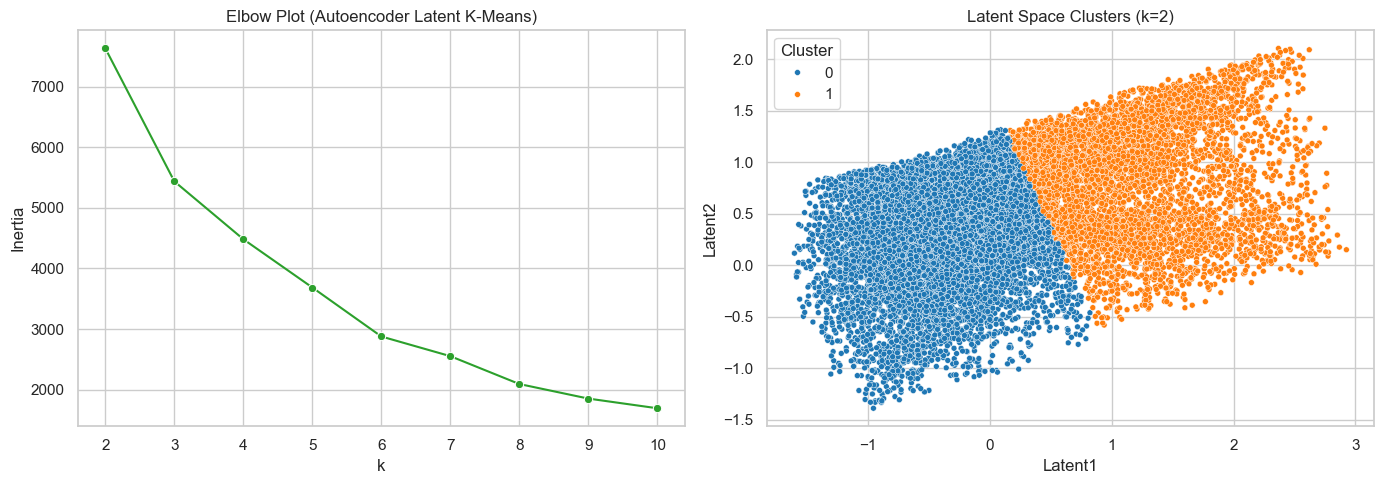

In [5]:
best_k_latent = int(latent_scores.loc[latent_scores['silhouette'].idxmax(), 'k'])

kmeans_latent = KMeans(n_clusters=best_k_latent, random_state=42, n_init='auto')
latent_labels = kmeans_latent.fit_predict(latent_df)

latent_clustered_df = X_scaled.copy()
latent_clustered_df['Cluster'] = latent_labels

latent_inertia = kmeans_latent.inertia_
latent_silhouette = silhouette_score(latent_df, latent_labels)
latent_v_measure = v_measure_score(reference_labels, latent_labels)

print(f'Best k (autoencoder latent): {best_k_latent}')
print(f'Inertia: {latent_inertia:.2f}')
print(f'Silhouette: {latent_silhouette:.4f}')
print(f'V-measure vs Gender: {latent_v_measure:.4f}')

latent_vis = latent_df.copy()
latent_vis['Cluster'] = latent_labels

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=latent_scores, x='k', y='inertia', marker='o', ax=axes[0], color='#2ca02c')
axes[0].set_title('Elbow Plot (Autoencoder Latent K-Means)')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')

sns.scatterplot(data=latent_vis, x='Latent1', y='Latent2', hue='Cluster', palette='tab10', s=18, ax=axes[1], legend='full')
axes[1].set_title(f'Latent Space Clusters (k={best_k_latent})')
axes[1].set_xlabel('Latent1')
axes[1].set_ylabel('Latent2')
plt.tight_layout()
plt.show()

In [6]:
output_path = os.path.join('data', 'autoencoder_clustered_data.csv')
latent_clustered_df.to_csv(output_path, index=False)
print(f'Saved autoencoder clustered data to: {output_path}')

Saved autoencoder clustered data to: data\autoencoder_clustered_data.csv
